## Hierarchical clustering analysis of within-scanner SC variability

In [93]:
import matplotlib.pyplot as plt
import numpy as np

from pathlib import Path
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import ward_tree
from sklearn.manifold import TSNE
from nireports.reportlets.nuisance import _ward_to_linkage


from confounds import get_confounds

# Set the random seed the same way as in the defacing registered report (RR)
day = 231108  # day and time the journal published our HCPh stage 1 registered report
time = 105017
random_seed = day + time
np.random.seed(random_seed)

hcph_path = Path("/data/datasets/hcph-dataset")
iqms_path = Path("/data/derivatives/hcph-mriqc/group_dwi.tsv")

### Simulate SC matrices with a set bias

We will use simulated SC matrices with an artifical set bias in the within-scanner variability to develop a Bland-Altman and hierarchical analyses capable of detecting such biases. Once the methodology is refined, we will apply it on the real HCPh data.

First, we generate a reference SC matrix on which we will later add noise to simulate between-session variability.

In [94]:
atlas_dim = 64  # Number of brain regions
scale = 0.01  # Mean track density
shape = 0.5  # Variability in density

# SC matrices typically follow a heavy-tailed distribution, with a few strong connections and many weak ones.
# We thus use a log-normal distribution to simulate SC value.
SC_matrix = np.random.lognormal(
    mean=np.log(scale), sigma=shape, size=(atlas_dim, atlas_dim)
)

# Make it symmetric
SC_matrix = (SC_matrix + SC_matrix.T) / 2

# Set diagonal to 0 (no self-connections)
np.fill_diagonal(SC_matrix, 0)

print(SC_matrix.shape)
print(SC_matrix)
assert SC_matrix.shape == (atlas_dim, atlas_dim)

(64, 64)
[[0.         0.0104071  0.01055773 ... 0.01409003 0.00815167 0.01753186]
 [0.0104071  0.         0.01386371 ... 0.00683563 0.01134391 0.01011825]
 [0.01055773 0.01386371 0.         ... 0.0112412  0.01084525 0.01313846]
 ...
 [0.01409003 0.00683563 0.0112412  ... 0.         0.01790434 0.008778  ]
 [0.00815167 0.01134391 0.01084525 ... 0.01790434 0.         0.00919632]
 [0.01753186 0.01011825 0.01313846 ... 0.008778   0.00919632 0.        ]]


We will duplicate the reference SC matrix 36 times to simulate the 36 acquisition sessions adding some noise in the duplicates to simulate between-session variability.

In the first simulation, we will make the connections with a lower density more variable across sessions.

In [95]:
# Number of sessions
num_sessions = 36

# Create a 3D array to store the SC matrices for all sessions
SC_matrices = np.zeros((num_sessions, atlas_dim, atlas_dim))

# Identify the 20th percentile threshold for the connection values in the reference SC matrix
percentile_20_threshold = np.percentile(SC_matrix[SC_matrix > 0], 20)

# Add noise to each duplicate
for i in range(num_sessions):
    noise = np.random.normal(loc=0, scale=0.0005, size=SC_matrix.shape)
    higher_noise = np.random.normal(loc=0, scale=0.002, size=SC_matrix.shape)

    # Apply higher noise to connections below the 20th percentile to simulate higher variability in weaker connections
    noise[SC_matrix <= percentile_20_threshold] += higher_noise[
        SC_matrix <= percentile_20_threshold
    ]

    SC_matrices[i, :, :] = SC_matrix + noise

    # SC cannot have negative values so if the value gets negative cast it to 0
    SC_matrices[i, :, :] = np.maximum(SC_matrices[i, :, :], 0)

print(SC_matrices.shape)
# Test whether the shape is as expected
assert SC_matrices.shape == (num_sessions, atlas_dim, atlas_dim)

(36, 64, 64)


### Prepare the SC matrices array for input in hierarchical clustering

To prepare the SC matrices array to input it in a hierarchical clustering analysis, we will keep only the lower triangle of each SC matrix and unravel it into a row vector.

In [96]:
# Extract the lower triangle of each SC matrix and unravel it into a row vector
SC_matrices_tril = np.array(
    [SC_matrices[i][np.tril_indices(atlas_dim, k=-1)] for i in range(num_sessions)]
)

print(SC_matrices_tril.shape)
# Test whether the shape is as expected
assert SC_matrices_tril.shape == (num_sessions, atlas_dim * (atlas_dim - 1) // 2)

(36, 2016)


### Perform hierarchical clustering to identify what sessions are more similar

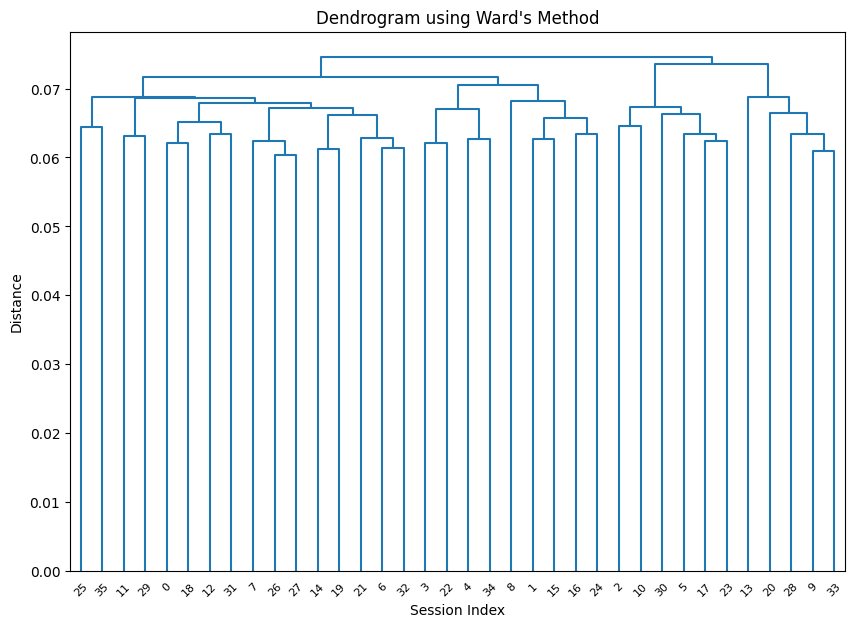

In [97]:
# Perform hierarchical clustering using Ward's method
#linkage_matrix_scipy = linkage(SC_matrices_tril, method="ward") # dendrogram(linkage_matrix) # we pre-registered that we would use scikit-learn

children, _, n_leaves, _, distances = ward_tree(SC_matrices_tril, return_distance=True)
linkage_matrix = _ward_to_linkage(children, n_leaves, distances)

# Generate and plot the dendrogram
plt.figure(figsize=(10, 7))
dendrogram(linkage_matrix)
plt.title("Dendrogram using Ward's Method")
plt.xlabel("Session Index")
plt.ylabel("Distance")
plt.show()

### What factor has an influence on the sessions similarity?

We will retrieve a serie of confound factors for each session to investigate whether they influenced how similar sessions are; in other words whether they can explain a higher or lower variability across session. Specifically, we are interested in the time of day, the average head-motion summarized by framewise displacement (FD), room temperature at start and PE direction.

In [98]:
confounds_df = get_confounds(iqms_path=iqms_path)
confounds_df = confounds_df[confounds_df["modality"] == "dwi"]
confounds_df.drop(columns=["task"], inplace=True)
# Verify that fd_mean has been defined for all dwi scans
assert confounds_df["fd_mean"].notna().all(), "There are NaN values in fd_mean column"

# Keep only the reliability sessions
confounds_df = confounds_df[confounds_df["session"].str.startswith("0")]
confounds_df.head()

,filename,acq_time,subject,session,modality,pe_dir,day_of_week,time_of_day,fd_mean,caffeine_intake_2h,caffeine_intake_24h,room_temp_before
192,sub-001/ses-001/dwi/sub-001_ses-001_acq-reliab...,2023-10-20T18:54:10.270000,001,001,dwi,LR,Friday,19:00:00,19.0832,0.0,2.0,19.4
206,sub-001/ses-003/dwi/sub-001_ses-003_acq-reliab...,2023-10-21T09:28:21.935000,001,003,dwi,LR,Saturday,09:00:00,19.1150,1.0,1.0,18.9
220,sub-001/ses-004/dwi/sub-001_ses-004_acq-reliab...,2023-10-21T11:29:47.890000,001,004,dwi,RL,Saturday,11:00:00,18.4681,0.0,1.0,18.9
234,sub-001/ses-005/dwi/sub-001_ses-005_acq-reliab...,2023-10-22T09:48:25.612500,001,005,dwi,PA,Sunday,10:00:00,5.3887,1.0,1.0,18.8
248,sub-001/ses-006/dwi/sub-001_ses-006_acq-reliab...,2023-10-22T11:34:20.785000,001,006,dwi,PA,Sunday,12:00:00,4.2292,1.0,1.0,19.0


In [99]:
# Map phase encoding directions to colors
pe_dir_colors = {'LR': 'blue', 'RL': 'green', 'AP': 'red', 'PA': 'purple'}
# TO DO: correctly match session numbers between confounds and SC matrices
session_colors = [pe_dir_colors[pe_dir] for pe_dir in confounds_df['pe_dir']]
"""
# Generate and plot the dendrogram with colors representing the phase encoding direction
plt.figure(figsize=(10, 7))
dendrogram(linkage_matrix, link_color_func=lambda k: session_colors[k])
plt.title("Dendrogram Colored by Phase Encoding Direction")
plt.xlabel("Session Index")
plt.ylabel("Distance")
plt.show()"
"""

'\n# Generate and plot the dendrogram with colors representing the phase encoding direction\nplt.figure(figsize=(10, 7))\ndendrogram(linkage_matrix, link_color_func=lambda k: session_colors[k])\nplt.title("Dendrogram Colored by Phase Encoding Direction")\nplt.xlabel("Session Index")\nplt.ylabel("Distance")\nplt.show()"\n'

### Perform clustering using t-distributed Stochastic Neighbor Embedding (t-SNE)

/tmp/ipykernel_339965/3346235071.py:11: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(SC_matrices_2d[:, 0], SC_matrices_2d[:, 1], c=session_colors[:num_sessions], cmap='viridis', s=50)


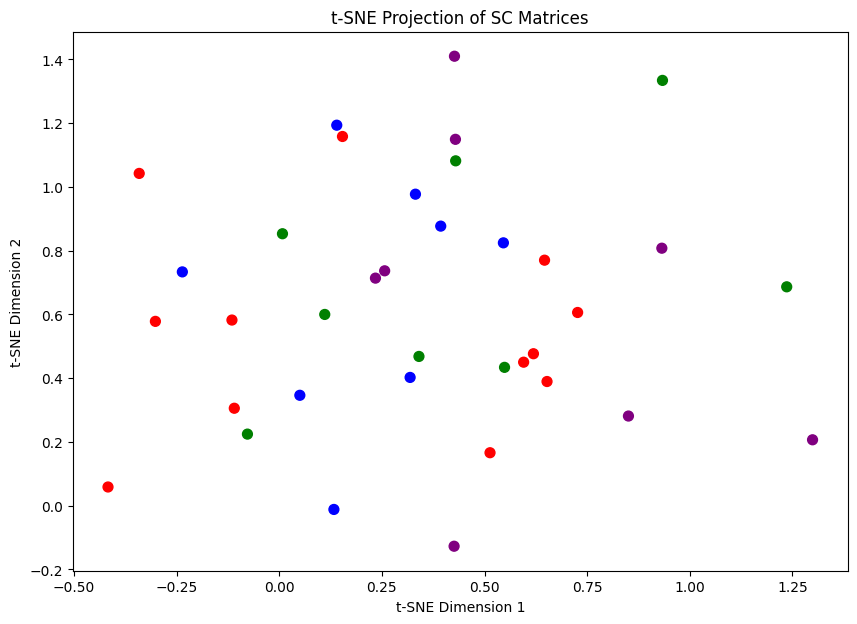

In [100]:
# Perform t-SNE to reduce dimensions to 2D
tsne = TSNE(n_components=2, random_state=random_seed)
SC_matrices_2d = tsne.fit_transform(SC_matrices_tril)

# TO DO: the documentation of t-SNE mention 
# It is highly recommended to use another dimensionality reduction method (e.g. PCA for dense data or TruncatedSVD for sparse data) 
# to reduce the number of dimensions to a reasonable amount (e.g. 50) if the number of features is very high. 

# Plot the result
plt.figure(figsize=(10, 7))
plt.scatter(SC_matrices_2d[:, 0], SC_matrices_2d[:, 1], c=session_colors[:num_sessions], cmap='viridis', s=50)
# TO DO: I have not checked if the coloring function is correct
plt.title("t-SNE Projection of SC Matrices")
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.show()